Model Evaluation:
Mean Absolute Error (MAE): 1508.3835269269218


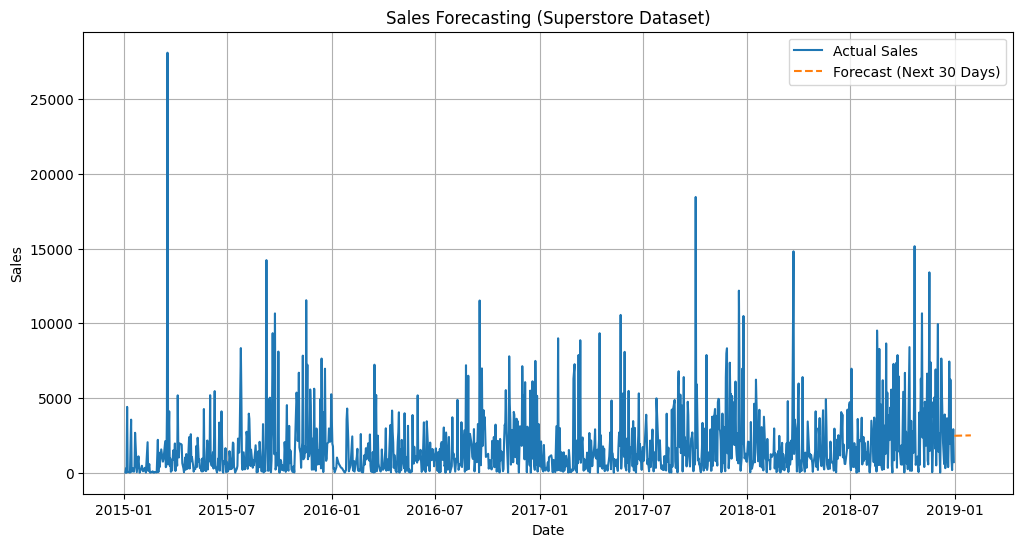


Business Insights:
- Sales trend shows overall pattern over time
- Forecast helps businesses plan inventory and demand
- Future predictions indicate expected sales movement


In [12]:
# ==============================
# 📦 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# ==============================
# 📂 2. Load Dataset
# ==============================
df = pd.read_csv("/content/dataset.csv", encoding='latin1')

# ==============================
# 🧹 3. Data Cleaning
# ==============================
# Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Remove missing values
df = df.dropna()

# Sort by date
df = df.sort_values('Order Date')

# ==============================
# 📊 4. Aggregate Sales by Date
# ==============================
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

# ==============================
# 🧠 5. Feature Engineering
# ==============================
# Create time-based feature
daily_sales['Days'] = (daily_sales['Order Date'] - daily_sales['Order Date'].min()).dt.days

# ==============================
# 🎯 6. Define Features & Target
# ==============================
X = daily_sales[['Days']]
y = daily_sales['Sales']

# ==============================
# 🤖 7. Train Model
# ==============================
model = LinearRegression()
model.fit(X, y)

# ==============================
# 📈 8. Predictions (Future 30 Days)
# ==============================
future_days = pd.DataFrame({
    'Days': np.arange(daily_sales['Days'].max() + 1,
                      daily_sales['Days'].max() + 31)
})

future_predictions = model.predict(future_days)

# Create future dates
future_dates = pd.date_range(start=daily_sales['Order Date'].max() + pd.Timedelta(days=1), periods=30)

# ==============================
# 📊 9. Model Evaluation
# ==============================
y_pred = model.predict(X)
mae = mean_absolute_error(y, y_pred)

print("Model Evaluation:")
print("Mean Absolute Error (MAE):", mae)

# ==============================
# 📉 10. Visualization
# ==============================
plt.figure(figsize=(12,6))

# Actual sales
plt.plot(daily_sales['Order Date'], y, label='Actual Sales')

# Forecast
plt.plot(future_dates, future_predictions, label='Forecast (Next 30 Days)', linestyle='dashed')

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Forecasting (Superstore Dataset)")
plt.legend()
plt.grid()

plt.show()

# ==============================
# 📊 11. Business Insights (Print)
# ==============================
print("\nBusiness Insights:")
print("- Sales trend shows overall pattern over time")
print("- Forecast helps businesses plan inventory and demand")
print("- Future predictions indicate expected sales movement")